In [452]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.cluster import DBSCAN
from sklearn.neighbors import NearestNeighbors
from sklearn.decomposition import PCA
import seaborn as sns
import os

In [453]:
file_path = "C:/Users/marle/Desktop/ML/Mall_Customers.csv"

if os.path.exists(file_path):
    df=pd.read_csv(file_path)
    print('wczytano dane z pliku:', file_path)
else:
    print("nie udało sie wczytać pliku, generujemy")
print("pierwsze 5 wierszy:")
print(df.head())
print("podstawowe statystyki:")
print(df.describe())

wczytano dane z pliku: C:/Users/marle/Desktop/ML/Mall_Customers.csv
pierwsze 5 wierszy:
   CustomerID   Genre  Age  Annual Income (k$)  Spending Score (1-100)
0           1    Male   19                  15                      39
1           2    Male   21                  15                      81
2           3  Female   20                  16                       6
3           4  Female   23                  16                      77
4           5  Female   31                  17                      40
podstawowe statystyki:
       CustomerID         Age  Annual Income (k$)  Spending Score (1-100)
count  200.000000  200.000000          200.000000              200.000000
mean   100.500000   38.850000           60.560000               50.200000
std     57.879185   13.969007           26.264721               25.823522
min      1.000000   18.000000           15.000000                1.000000
25%     50.750000   28.750000           41.500000               34.750000
50%    100.500000  

In [454]:

if 'CustomerID' in df.columns:
    df = df.drop('CustomerID', axis=1) #usunieto kolumne id

if 'Genre' in df.columns: #kodowanie płci
    #labelencoder przypisuje: male = 0, a female = 1
    le=LabelEncoder()
    df['Genre'] = le.fit_transform(df['Genre'])
else:
    print("koolumna genre ni istnieje")
print("typy danych po przetworzeniu:")
print(df.dtypes)

typy danych po przetworzeniu:
Genre                     int64
Age                       int64
Annual Income (k$)        int64
Spending Score (1-100)    int64
dtype: object


In [455]:
#wybór cech do grupowania - bierzemy wszystkie
features = df.columns.tolist()
X=df[features].values

print("kształt macierxy cech:", X.shape)
print("pierwsze 5 wierszy danych numeryczne: ",X[:5])
#skalowanie danych:
scaler= StandardScaler()
X_scaled = scaler.fit_transform(X)

kształt macierxy cech: (200, 4)
pierwsze 5 wierszy danych numeryczne:  [[ 1 19 15 39]
 [ 1 21 15 81]
 [ 0 20 16  6]
 [ 0 23 16 77]
 [ 0 31 17 40]]


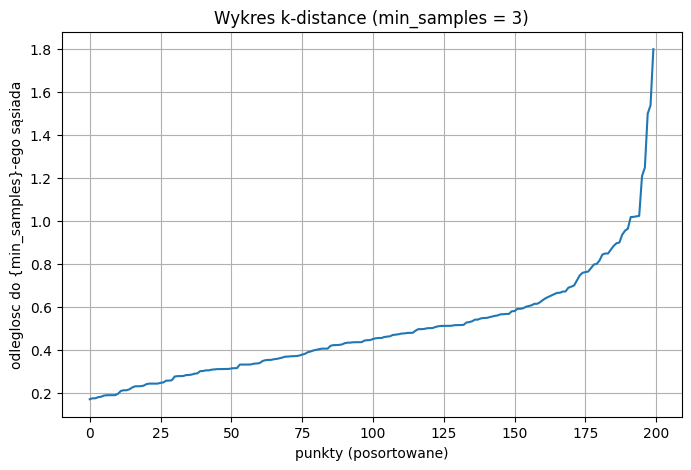

In [456]:
#dobór parametru eps
min_samples = 3
neigh = NearestNeighbors(n_neighbors=min_samples)
nbrs = neigh.fit(X_scaled)
distances, indices = nbrs.kneighbors(X_scaled) #dla kazdego punktu dostajemy indeksy i odległośc najblizszych sasiadów
k_dist = np.sort(distances[:, min_samples-1],axis=0)

plt.figure(figsize=(8,5))
plt.plot(k_dist)
plt.title('Wykres k-distance (min_samples = {})'.format(min_samples))
plt.xlabel('punkty (posortowane)')
plt.ylabel('odleglosc do {min_samples}-ego sąsiada')
plt.grid(True)
#plt.show()

eps= 0.7 # na podstawie wykresu


In [457]:
db = DBSCAN(eps=eps, min_samples=min_samples)
labels = db.fit_predict(X_scaled) 

unique_labels=set(labels)
n_clusters= len(unique_labels)-(1 if -1 in unique_labels else 0)
n_noise = list(labels).count(-1)
print("liczba znalezionych klastrów: ", n_clusters)
print("liczba szumu: ",n_noise)
#dodanie etykiet do danych i zapis
df['cluster'] = labels
for cluster in sorted(unique_labels):
    print("\n============")
    if cluster == -1:
        print("Szumiące punkty (nieprzypisane do klastra):")
    else:
        print(f"Klaster {cluster}")
    cluster_points=df[df['cluster']==cluster]
    print("Liczba punktów:", len(cluster_points))
    if cluster == -1:
        print("osoby szumiace: ")
    else:
        print("osoby w klastrze: ")
    print(cluster_points)
output_file = "mail_customers_with_clusters.csv"
df.to_csv(output_file, index = False)
print("zapisano wyniki do pliku: {}".format(output_file))

liczba znalezionych klastrów:  9
liczba szumu:  14

Szumiące punkty (nieprzypisane do klastra):
Liczba punktów: 14
osoby szumiace: 
     Genre  Age  Annual Income (k$)  Spending Score (1-100)  cluster
0        1   19                  15                      39       -1
2        0   20                  16                       6       -1
6        0   35                  18                       6       -1
11       0   35                  19                      99       -1
14       1   37                  20                      13       -1
18       1   52                  23                      29       -1
19       0   35                  23                      98       -1
20       1   35                  24                      35       -1
192      1   33                 113                       8       -1
194      0   47                 120                      16       -1
196      0   45                 126                      28       -1
197      1   32                 126     

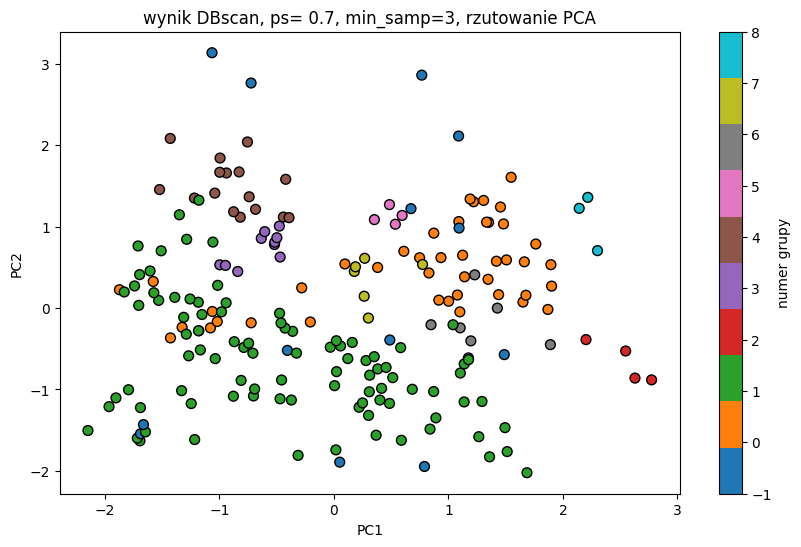

In [458]:

#wizualizacja - redukcja wymiaru do 2D za pomocą pca
pca=  PCA(n_components = 2)
X_pca = pca.fit_transform(X_scaled)
plt.figure(figsize=(10,6))
scatter= plt.scatter(X_pca[:,0],X_pca[:,1], c=labels, cmap='tab10', edgecolors='k', s=50)
plt.colorbar(scatter, label='numer grupy')
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.title('wynik DBscan, ps= {}, min_samp={}, rzutowanie PCA'.format(eps, min_samples))
plt.show()

In [459]:
#własnoręcznie zaimplementowany dbscan
#1. odległośc eukalidesowa miedzy dwoma punktami
def eucalidean_distance(p1,p2):
    return np.sqrt(np.sum((p1-p2)**2))
    
#szukanie sąsiadów
def region_query(X, point_idx, eps):
    neighbors = []
    for i in range(len(X)):
        if eucalidean_distance(X[point_idx], X[i]) <= eps:
            neighbors.append(i)
    return neighbors
    
    #budowaklastra
def expand_cluster(X, labels, point_idx, neighbors, cluster_id, eps, min_samples):
    #przypisanie kolumny labels dla punktu na klaster
    labels[point_idx] = cluster_id
    #iterujemy po sąsiadach, lista moze sie powiekszać jeśli sąsiad ma wiecej sąsiadów niż min_samples
    i=0
    while i <len(neighbors):
        neighbor_idx = neighbors[i]
        #jeśli sąsiad jest szumem zmieniamy go na czesc klastra
        if labels[neighbor_idx] == -1:
            labels[neighbor_idx] = cluster_id
#jeśli punkt jeszcze nie był odwiedzony - przypisujemy do klastra i patrzymy czy ma sąsiadów, jeśli ma to sąsiadów dodajemy do klastra, jeśli nie ma, to pozostaje w tym klastrze i koniec jego historii
        elif labels[neighbor_idx] == 0:
            labels[neighbor_idx] = cluster_id
            new_neighbors = region_query(X, neighbor_idx, eps)

            if len(new_neighbors) >= min_samples:
                neighbors += new_neighbors
        i += 1
def dbscan_manual(X, eps, min_samples):
    labels = np.zeros(len(X))
    cluster_id = 0

    for i in range(len(X)):
        #pomijamy odwiedzone punkty
        if labels[i] != 0:
            continue
#znajdujemy sąsiadów
        neighbors = region_query(X, i , eps)
#jeśli za mało sąsiadów - szum, jeśli punkt rdzeniowy - nowy klaster
        if len(neighbors) < min_samples:
            labels[i] = -1
        else:
            cluster_id +=1
            expand_cluster(X, labels, i , neighbors, cluster_id, eps, min_samples)
    return labels



In [460]:
#manualne uruchomienie
labels2 = dbscan_manual(X_scaled, eps, min_samples)
#labels - tablica z numerami klastrów dla każdego punktu w zbioerze, jeśli jest -1 to oznacza że punkt jst szumm
unique_labels=set(labels2)
n_clusters= len(unique_labels)-(1 if -1 in unique_labels else 0)
n_noise = list(labels2).count(-1)
print("liczba znalezionych klastrów: ", n_clusters)
print("liczba szumu: ",n_noise)
#dodanie etykiet do danych i zapis
df['cluster'] = labels2
for cluster in sorted(unique_labels):
    print("\n============")
    if cluster == -1:
        print("Szumiące punkty (nieprzypisane do klastra):")
    else:
        print(f"Klaster {cluster}")
    cluster_points=df[df['cluster']==cluster]
    print("Liczba punktów:", len(cluster_points))
    if cluster == -1:
        print("osoby szumiace: ")
    else:
        print("osoby w klastrze: ")
    print(cluster_points)
output_file = "mail_customers_with_clusters_manual.csv"
df.to_csv(output_file, index = False)
print("zapisano wyniki do pliku: {}".format(output_file))





liczba znalezionych klastrów:  9
liczba szumu:  14

Szumiące punkty (nieprzypisane do klastra):
Liczba punktów: 14
osoby szumiace: 
     Genre  Age  Annual Income (k$)  Spending Score (1-100)  cluster
0        1   19                  15                      39     -1.0
2        0   20                  16                       6     -1.0
6        0   35                  18                       6     -1.0
11       0   35                  19                      99     -1.0
14       1   37                  20                      13     -1.0
18       1   52                  23                      29     -1.0
19       0   35                  23                      98     -1.0
20       1   35                  24                      35     -1.0
192      1   33                 113                       8     -1.0
194      0   47                 120                      16     -1.0
196      0   45                 126                      28     -1.0
197      1   32                 126     

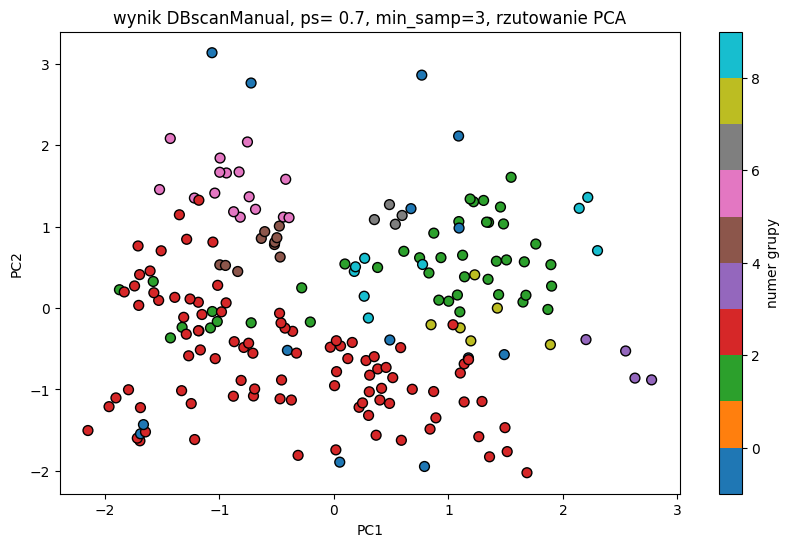

In [461]:

#wizualizacja - redukcja wymiaru do 2D za pomocą pca
pca=  PCA(n_components = 2)
X_pca = pca.fit_transform(X_scaled)
plt.figure(figsize=(10,6))
scatter= plt.scatter(X_pca[:,0],X_pca[:,1], c=labels2, cmap='tab10', edgecolors='k', s=50)
plt.colorbar(scatter, label='numer grupy')
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.title('wynik DBscanManual, ps= {}, min_samp={}, rzutowanie PCA'.format(eps, min_samples))
plt.show()

In [462]:
np.random.seed(42)

def make_cluster(center, n, scale):
    return np.random.randn(n, 2) * scale + center

X = np.vstack([
    make_cluster([0, 0], 100, 0.2),
    make_cluster([3, 3], 120, 0.3),
    make_cluster([-3, 2], 90, 0.25),
    make_cluster([2, -3], 110, 0.4),
    make_cluster([-2, -2], 95, 0.2),
    make_cluster([5, 0], 130, 0.35),
    make_cluster([-5, 0], 80, 0.3),
    make_cluster([0, 5], 100, 0.25),
    make_cluster([0, -5], 105, 0.3),
    make_cluster([4, -4], 70, 0.2),
])
print(X.shape)
# zamiana na DataFrame
df = pd.DataFrame(X, columns=['Feature1', 'Feature2'])



(1000, 2)


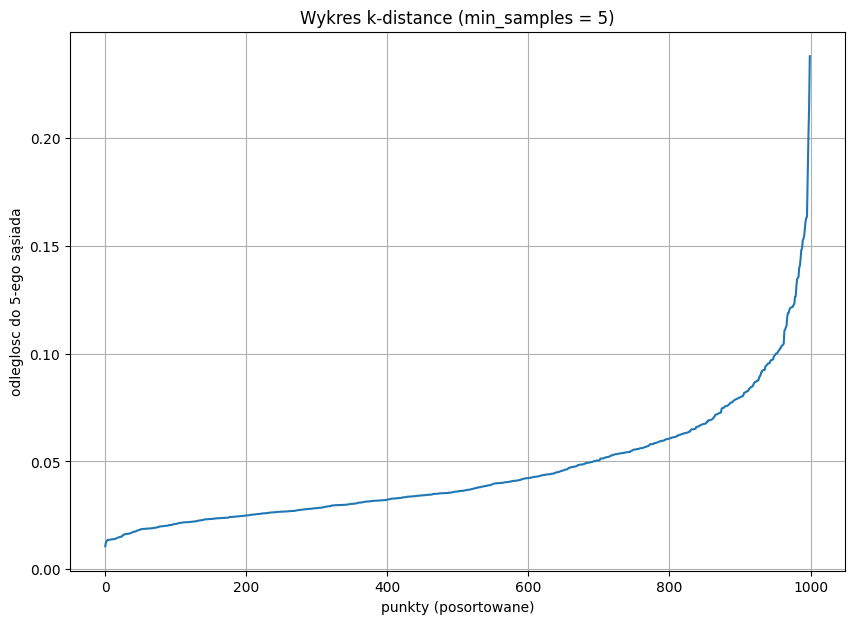

In [463]:

# skalowanie danych
scaler = StandardScaler()
X_scaled2 = scaler.fit_transform(df[['Feature1', 'Feature2']])

min_samples = 5

# nearest neighbors
neighbors = NearestNeighbors(n_neighbors=min_samples)
neighbors.fit(X_scaled2)
distances, indices = neighbors.kneighbors(X_scaled2)
k_dist = np.sort(distances[:, min_samples - 1])

#  wykres
plt.figure(figsize=(10,7))
plt.plot(k_dist)

plt.title(f'Wykres k-distance (min_samples = {min_samples})')
plt.xlabel('punkty (posortowane)')
plt.ylabel(f'odleglosc do {min_samples}-ego sąsiada')

plt.grid(True)
plt.show()






Liczba klastrów: 10
Szum: 15


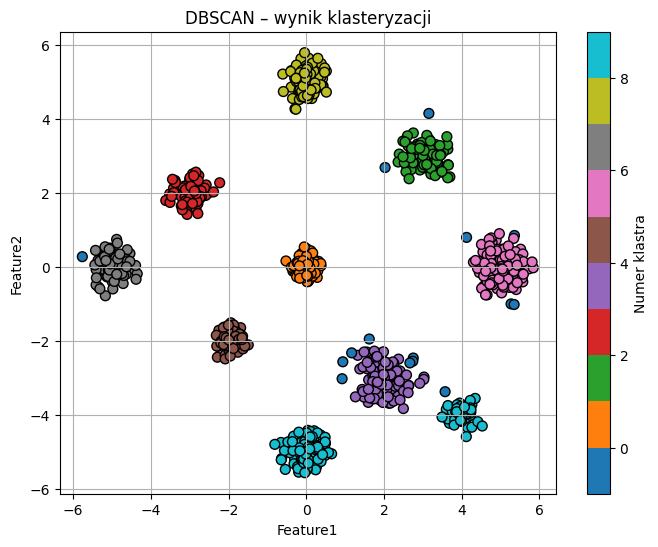

In [464]:


# DBSCAN
eps = 0.10  # lepszy punkt startowy
db = DBSCAN(eps=eps, min_samples=min_samples)

labels3 = db.fit_predict(X_scaled2)
df['DBSCAN_Cluster'] = labels3


# wynik
n_clusters = len(set(labels3)) - (1 if -1 in labels3 else 0)
n_noise = list(labels3).count(-1)

print("Liczba klastrów:", n_clusters)
print("Szum:", n_noise)

# wizualizacja
plt.figure(figsize=(8,6))
plt.scatter(
    df['Feature1'],
    df['Feature2'],
    #c=df['DBSCAN_Cluster'],
    c=labels3,
    cmap='tab10',
    s=50,
    edgecolors='k'
)
plt.xlabel('Feature1')
plt.ylabel('Feature2')
plt.title("DBSCAN – wynik klasteryzacji")
plt.colorbar(label='Numer klastra')
plt.grid(True)
plt.show()




Liczba klastrów: 10
Szum: 15


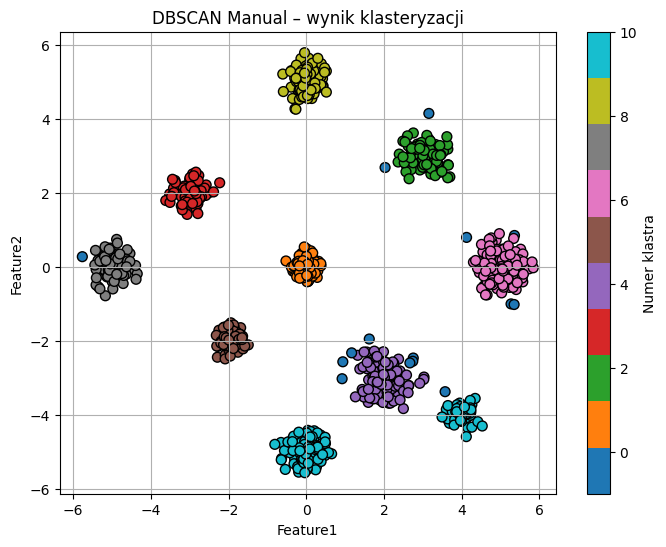

Zapisano dane do pliku: dbscan10_results.csv


In [ ]:

#DBSCAN manualny
labels4 = dbscan_manual(X_scaled2, eps=eps, min_samples=min_samples)
df['DBSCAN_Manual_Cluster'] = labels4

# wynik
n_clusters = len(set(labels4)) - (1 if -1 in labels4 else 0)
n_noise = list(labels4).count(-1)

print("Liczba klastrów:", n_clusters)
print("Szum:", n_noise)
print("\n=== LICZNOŚĆ KLASTRÓW ===")
for cluster_id, count in sorted(cluster_counts.items()):
    if cluster_id == -1:
        print(f"Szum (-1): {count} punktów")
    else:
        print(f"Klaster {cluster_id}: {count} punktów")

# wizualizacja
plt.figure(figsize=(8,6))
plt.scatter(
    df['Feature1'],
    df['Feature2'],
    #c=df['DBSCAN_Manual_Cluster'],
    c=labels4,
    cmap='tab10',
    s=50,
    edgecolors='k'
)
plt.xlabel('Feature1')
plt.ylabel('Feature2')
plt.title("DBSCAN Manual – wynik klasteryzacji")
plt.colorbar(label='Numer klastra')
plt.grid(True)
plt.show()

# zapis do pliku CSV
output_file = "dbscan10_results.csv"
df.to_csv(output_file, index=False)

print(f"Zapisano dane do pliku: {output_file}")